# Eksperyment: Wpływ funkcji aktywacji na wyniki MLP (z pliku CSV)
W tym notatniku zbadamy wpływ funkcji aktywacji (`sigmoid`, `gelu`, `identity`) na proces uczenia modelu MLP przy użyciu danych z pliku CSV zawierającego kolumny `x`, `y`, `cls`. Zawiera on wizualizacje zbioru uczącego, przebiegu błędu, ewolucji wag i granic decyzyjnych.

In [4]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlp import MLP
from mlp.utils import plot_loss, plot_weight_evolution, plot_decision_boundary

# Konfiguracja
SEED = 77
np.random.seed(SEED)

CSV_PATH = "../lab1_data/Classification/data.circles.train.100.csv"  # <- nazwa datasetu

config = {
    "layer_sizes": [2, 8, 8, 5],
    "epochs": 5000,
    "learning_rate": 0.05,
    "use_bias": True,
}

activations = ["sigmoid", "gelu", "identity"]


## Wczytanie i wizualizacja danych

          x         y  cls
0  0.465371 -0.674822    1
1  0.527244 -0.877283    1
2 -0.693633 -0.095038    2
3 -0.179198 -0.261372    4
4 -0.700064  0.243435    1


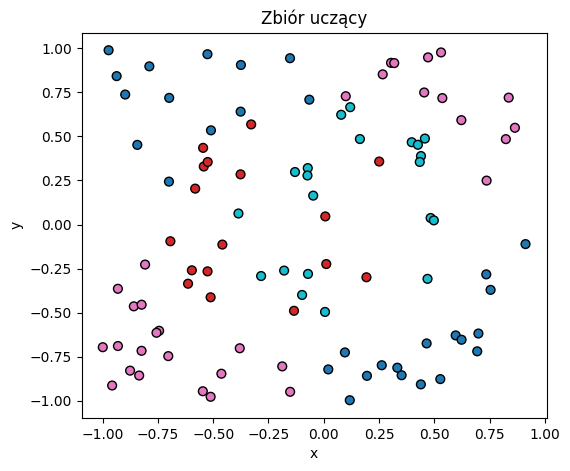

In [5]:

data = pd.read_csv(CSV_PATH)
print(data.head())

X = data[["x", "y"]].values
y = (data["cls"].values - 1).reshape(-1, 1)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap="tab10", s=40, edgecolors="k")
plt.title("Zbiór uczący")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


## Trening modeli dla różnych funkcji aktywacji

In [6]:

results = {}

for act in activations:
    print(f"\n=== Trening dla aktywacji: {act} ===")
    model = MLP(
        layer_sizes=config["layer_sizes"],
        task="multiclass",
        activation=act,
        learning_rate=config["learning_rate"],
        seed=SEED,
    )

    losses, weight_hist = model.fit(X, y, epochs=config["epochs"], verbose=False)
    preds = model.predict(X)
    acc = np.mean(preds == y)

    results[act] = {
        "model": model,
        "losses": losses,
        "weights": weight_hist,
        "accuracy": acc,
    }

    print(f"Koncowa strata: {losses[-1]:.6f} | Dokladnosc: {acc:.4f}")



=== Trening dla aktywacji: sigmoid ===
Koncowa strata: 1.355521 | Dokladnosc: 0.3200

=== Trening dla aktywacji: gelu ===


AssertionError: Invalid activation function: gelu. Allowed: 'sigmoid'

## Wizualizacja wyników


### Funkcja aktywacji: sigmoid


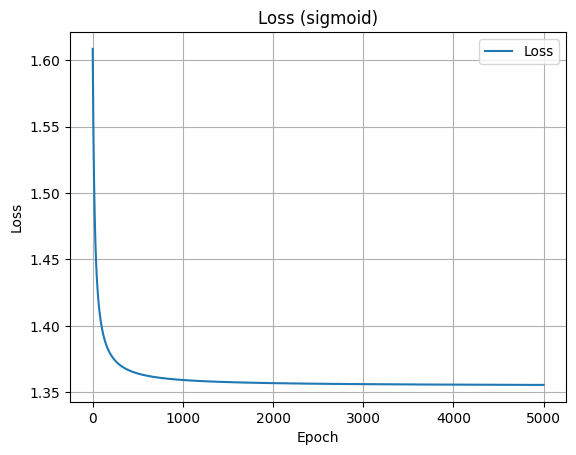

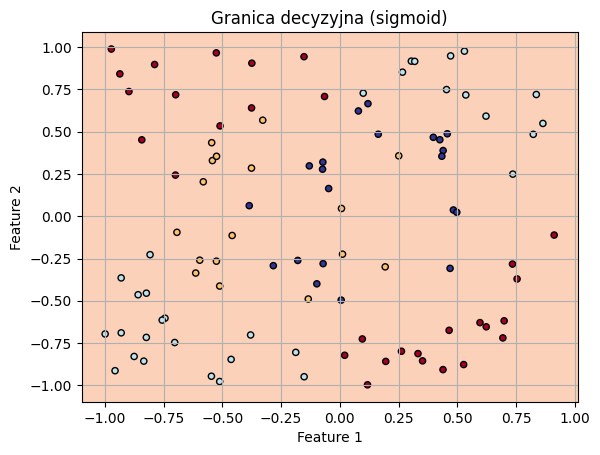

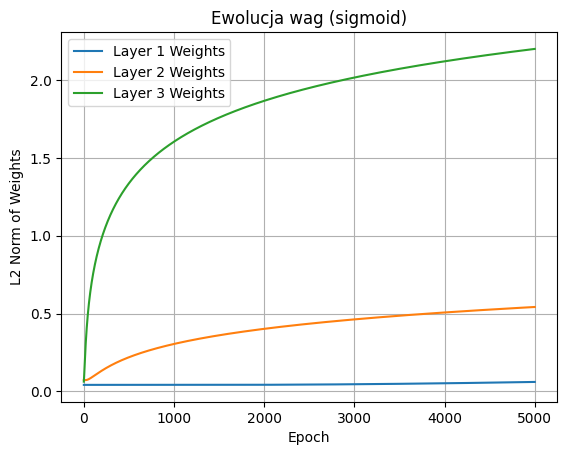


### Funkcja aktywacji: gelu


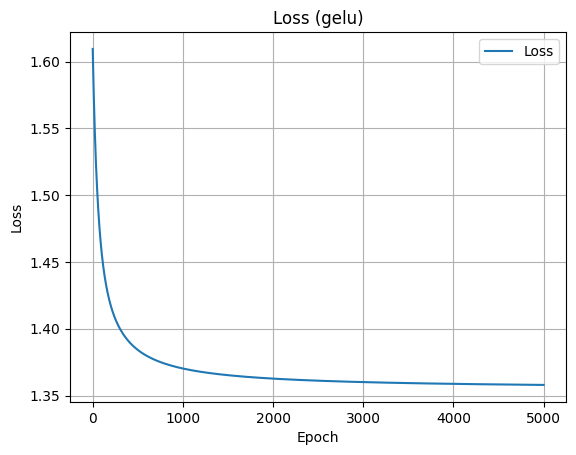

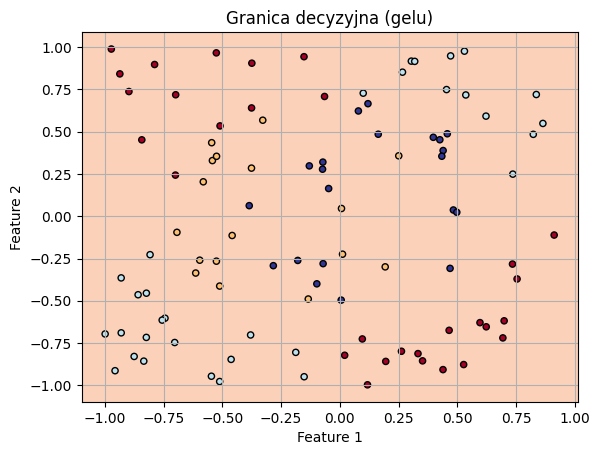

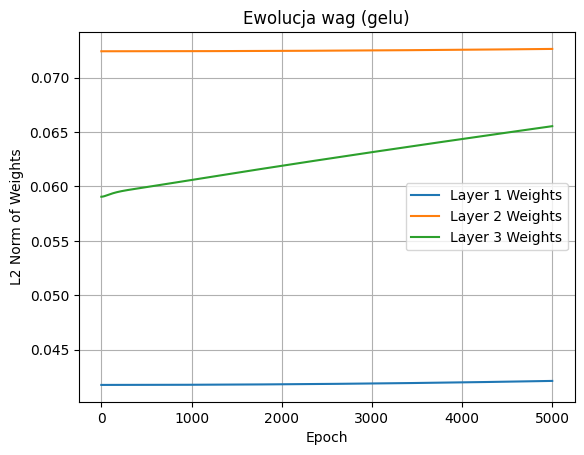


### Funkcja aktywacji: identity


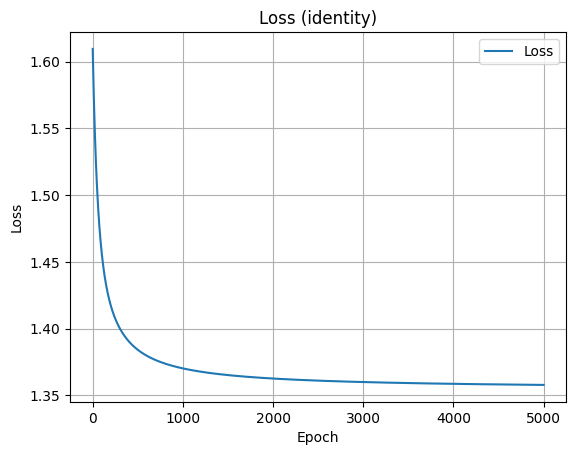

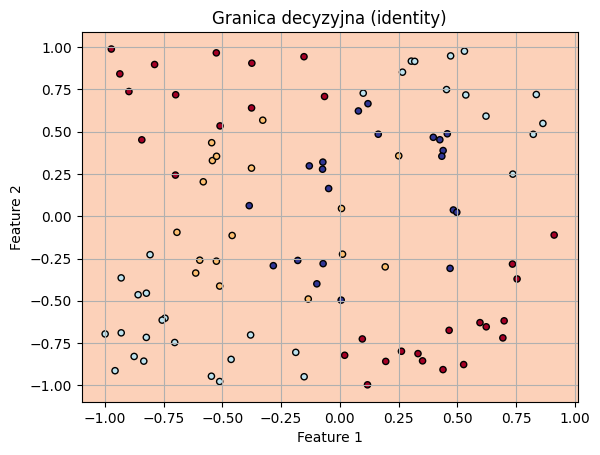

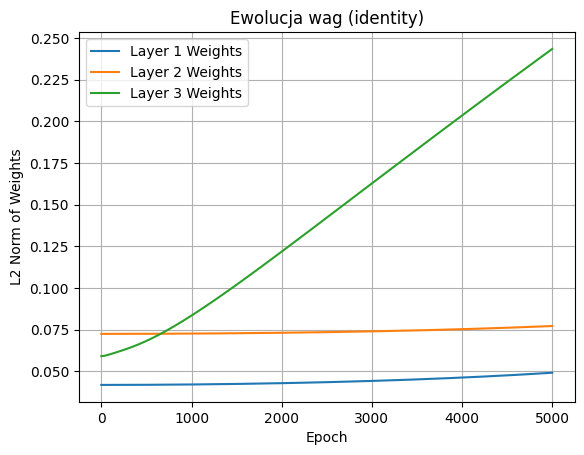

In [ ]:

for act, data in results.items():
    print(f"\n### Funkcja aktywacji: {act}")
    plot_loss(data["losses"], title=f"Loss ({act})")
    plot_decision_boundary(data["model"], X, y, title=f"Granica decyzyjna ({act})")
    plot_weight_evolution(data["weights"], title=f"Ewolucja wag ({act})")


## Podsumowanie

Eksperymenty zmieniając `config['layer_sizes']`, `epochs`, `learning_rate`, `use_bias`.
